# Content Analysis — Nigeria (coding units)

**Norman Lear Center × Gates Foundation — Manfluencer project**

Builds the Nigeria content-analysis corpus as **coding units**, matching the Kibe_Jagero reference format:

| Segment ID | Influencer | Platform | Content Type | Theme(s) | Context (NOT CODED) | Verbatim Text (CODE THIS) |

## Per-creator plan

| Creator | Source | Segmentation | Target units |
|---|---|---|---:|
| Banky Wellington | 5 YouTube transcripts | `gpt-4o` breaks each transcript into topically coherent coding units | 8 per video → **40** |
| Deyemi Okanlawon | X OG posts | one unit per post, themes + context via `gpt-4o` | **4** (memo listed 4) |
| Wizarab | X OG posts | same | **5** |
| Shola | X OG posts | same | **5** |
| Agba John Doe | X OG posts | same | **5** |

Each Banky coding unit is a topically coherent argumentative move (~80-150 words) with punctuation restored, capitalization restored, words preserved **exactly**, and Pidgin / Yoruba / Swahili code-switching left intact. Context and 2-4 theme tags are generated per unit.

LLM outputs are cached under `temp/content_analysis_nigeria/` so re-runs are free.


## 0 — Setup

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
print("Project root:", ROOT)
load_dotenv(ROOT / ".env")
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not set in .env"
client = OpenAI()


Project root: /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project


## 1 — Config

In [2]:
TRANSCRIPTS_DIR = ROOT / "Generated Transcripts" / "Nigeria"
AUDIENCE_DIR = ROOT / "Nigeria Audience Comments"
OUTPUT_DIR = ROOT / "Content Analysis - Nigeria"
PLOTS_DIR = ROOT / "Content Analysis Plots - Nigeria"
CACHE_DIR = ROOT / "temp" / "content_analysis_nigeria"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

BANKY_SPEAKER = "Banky W (Olubankole Wellington)"
SEGMENTS_PER_VIDEO = 8
LLM_MODEL = "gpt-4o"

BANKY_VIDEOS = [
    {"title": "Final Say Faith - Banky & Adesua Wellington",
     "file": "Final Say Faith - Banky & Adesua Wellington.txt",
     "link": "https://www.youtube.com/watch?v=LFs0k-eluu4",
     "context_hint": "Church sermon / testimony on marriage, IVF struggles, and faith, co-delivered with Adesua Wellington."},
    {"title": "My Story - a journey through Hope & Faith",
     "file": "My Story - a journey through Hope & Faith - Banky Wellington.txt",
     "link": "https://www.youtube.com/watch?v=a5PryKc1Ev8",
     "context_hint": "First-person testimony sermon about Banky's cancer diagnosis, recovery, and faith journey."},
    {"title": "The Prison of Pornography - Road to Freedom Finale",
     "file": "The Prison of Pornography - Road to Freedom Finale.txt",
     "link": "https://www.youtube.com/watch?v=9e9zAjM9wuA",
     "context_hint": "Church sermon on pornography addiction, sexual temptation, and male spiritual discipline."},
    {"title": "Face it Like a Man - Banky Wellington",
     "file": "Face it Like a Man - Banky Wellington.txt",
     "link": "https://www.youtube.com/watch?v=SoVSXTTH2dg",
     "context_hint": "Father's Day sermon on Christian manhood, fatherhood, providership, and male spiritual responsibility."},
    {"title": "Faith after a Fall - Banky Wellington",
     "file": "Faith after a Fall - Banky Wellington.txt",
     "link": "https://www.youtube.com/watch?v=qFHXI0jHJRM",
     "context_hint": "Sermon on Peter's denial of Christ, applied to male failure, shame, and restoration in faith."},
]

X_POSTS = {
    "Deyemi Okanlawon": {
        "orientation": "Progressive",
        "handle": "_deyemi",
        "platform": "X (Twitter)",
        "content_type": "Social Post / Tweet",
        "posts": [
            {"link": "https://x.com/_deyemi/status/2025894619490226565",
             "fallback": "Men MUST hold other men accountable... FACT! And 2geda we ALL shd hold ALL abusers of children, women & men accountable, fix judicial sys, destroy victim stigma, educate on consent, dismantle harmful norms. Ending rape starts with culture, not just laws #fromavictim #EndRape",
             "audience_file": "Men Must Hold Men Accountable.xlsx"},
            {"link": "https://x.com/_deyemi/status/2025896860288708660",
             "fallback": "When women say \"STOP rap*ng women\"... Your response cannot be \"what abt men/children\" neither can it be \"what abt false accusers\" nor anything else. Your reply MUST only be YES!!! You can start your own separate conversation abt anything else at another time/place. #EndRape",
             "audience_file": "Stop Raping Women Response.xlsx"},
            {"link": "https://x.com/_deyemi/status/2025962677671969172",
             "fallback": "Starting to see that 1 major issue is us never addressing male trauma! A lot of hurt men (some with stolen childhoods) are now either being reactive by projecting or blindly striking back. Been there n still healing so I am able to understand it. There must be a solution!",
             "audience_file": None},
            {"link": "https://x.com/_deyemi/status/20259491176381360",
             "fallback": "LOL... I've seen the crazies on the other side but did not know how many crazies are on our side until now! Dear Nigerian men & women wt sense dont be distracted - stand 2geda, defend the defenceless n build a stronger society with intelligence n moral standards worth emulating!",
             "audience_file": None},
        ],
    },
    "Wizarab": {
        "orientation": "Regressive",
        "handle": "Wizarab10",
        "platform": "X (Twitter)",
        "content_type": "Social Post / Tweet",
        "posts": [
            {"link": "https://x.com/Wizarab10/status/20281844110200711",
             "fallback": "In extra marital affair, women are the problem either as the side chic or the married person.",
             "audience_file": None},
            {"link": "https://x.com/Wizarab10/status/20276692910598554",
             "fallback": "Before the advent of sex toys, women got off by raping young boys when they were horny.",
             "audience_file": "Sex Toys and Raping Young Boys.xlsx"},
            {"link": "https://x.com/Wizarab10/status/20308926907667255",
             "fallback": "When you were with the kids, he was paying child support... This brings me to my argument that the concept of child support is fraudulent.",
             "audience_file": "Child Support and Divorce.xlsx"},
            {"link": "https://x.com/Wizarab10/status/20294818211555002",
             "fallback": "Na me go take you serious if you don't spend on me and make my life easier?",
             "audience_file": None},
            {"link": "https://x.com/Wizarab10/status/20312647424807530",
             "fallback": "LOL. Yes. Men don't pick women the way women pick men.",
             "audience_file": None},
        ],
    },
    "Shola": {
        "orientation": "Regressive",
        "handle": "itsSh0la",
        "platform": "X (Twitter)",
        "content_type": "Social Post / Tweet",
        "posts": [
            {"link": "https://x.com/itsSh0la/status/18512163035639071",
             "fallback": "Men are in love, women are in business.",
             "audience_file": None},
            {"link": "https://x.com/itsSh0la/status/20314429899820894",
             "fallback": "They will teach themselves everything except how to keep a home, remain submissive, and stay faithful.",
             "audience_file": None},
            {"link": "https://x.com/itsSh0la/status/20305626486563352",
             "fallback": "We are slowly entering the era where 7 women will desperately beg one man to marry them.",
             "audience_file": "7 Women Will Beg One Man to Marry.xlsx"},
            {"link": "https://x.com/itsSh0la/status/20295337062815006",
             "fallback": "This is why I laugh whenever women say I was there for him when he had nothing.",
             "audience_file": None},
            {"link": "https://x.com/itsSh0la/status/17702467250950270",
             "fallback": "Nigerian Church Girls as Red Flags.",
             "audience_file": None},
        ],
    },
    "Agba John Doe": {
        "orientation": "Regressive",
        "handle": "jon_d_doe",
        "platform": "X (Twitter)",
        "content_type": "Social Post / Tweet",
        "posts": [
            {"link": "https://x.com/jon_d_doe/status/15567399088108175",
             "fallback": "For married women, never be too quick to leave your marriage because your husband cheated.",
             "audience_file": "Never Leave Marriage Because Husband Cheated.xlsx"},
            {"link": "https://x.com/jon_d_doe/status/20310864507085417",
             "fallback": "Most women who do BBL are doing it because they want to prostitute their bodies at a higher price.",
             "audience_file": None},
            {"link": "https://x.com/jon_d_doe/status/20292112731838098",
             "fallback": "Any single woman in today's Nigeria who earns above N1.5m per month is likely to be over 30 years old.",
             "audience_file": "Single Woman Earning Above 1.5M.xlsx"},
            {"link": "https://x.com/jon_d_doe/status/20303481982466009",
             "fallback": "A woman that has committed 20 abortions will most likely get married before a single mother that has committed no abortion.",
             "audience_file": None},
            {"link": "https://x.com/jon_d_doe/status/20332426465341400",
             "fallback": "If the man that wants to marry you has elder sisters that are either unmarried, divorced or single mothers, please rethink your decision.",
             "audience_file": None},
        ],
    },
}

total = SEGMENTS_PER_VIDEO * len(BANKY_VIDEOS) + sum(len(m["posts"]) for m in X_POSTS.values())
print(f"Target: {SEGMENTS_PER_VIDEO * len(BANKY_VIDEOS)} Banky segments + {sum(len(m['posts']) for m in X_POSTS.values())} X units = {total} coding units total")


Target: 40 Banky segments + 19 X units = 59 coding units total


## 2 — Banky coding units (LLM segmentation)

Each Banky transcript is passed whole to `gpt-4o` with strict instructions:
- Segment into exactly 8 topically coherent coding units.
- Each unit is a single argumentative / narrative move, roughly 80-150 words.
- Restore punctuation and capitalization — but **do not change, add, remove, or paraphrase any words**. Preserve Pidgin / Yoruba / Swahili code-switching exactly.
- Provide a one-sentence context describing what Banky is arguing in that unit.
- Provide 2-4 concise theme tags (semicolon separated).

JSON schema enforced. Output cached per-video.


In [3]:
def _extract_banky_raw(path, banky_label=BANKY_SPEAKER):
    text = Path(path).read_text(encoding="utf-8")
    body_parts = re.split(r"\n\s*\n", text, maxsplit=1)
    body = body_parts[1] if len(body_parts) == 2 else text
    turns = [t.strip() for t in re.split(r"\n\s*\n", body) if t.strip()]
    banky_chunks = []
    for turn in turns:
        m = re.match(r"^([^:\n]{2,120}):\s*(.+)$", turn, flags=re.DOTALL)
        if not m:
            continue
        speaker, content = m.group(1).strip(), m.group(2).strip()
        if speaker != banky_label:
            continue
        content = re.sub(r"\s+", " ", content).strip()
        if content:
            banky_chunks.append(content)
    return " ".join(banky_chunks)


BANKY_SYSTEM_PROMPT = '''You are a qualitative research assistant preparing coding units from a masculinity / faith sermon by Nigerian creator Banky Wellington.

You will receive a raw speech-to-text transcript of Banky's speech. It has almost no punctuation or capitalization. Your job is to produce EXACTLY N topically coherent coding units — NOT the full transcript.

## Hard size limits (critical)
- EXACTLY N units. Not more, not fewer.
- Each `verbatim_text` MUST be between 60 and 160 words. Absolutely never over 160 words.
- Pick the N most analytically rich passages from the transcript that relate to masculinity, gender, faith, relationships, fatherhood, or male spiritual life. You are SAMPLING, not rewriting the whole sermon.
- Skip long stories with no masculinity content, skip greetings, skip prayer formulas, skip song lyrics.

## Verbatim text rules — DO NOT VIOLATE
- Words inside each `verbatim_text` must appear in the original transcript, in order, contiguously — it is a literal excerpt.
- Do NOT change, add, remove, reorder, or paraphrase any words.
- Restore sentence-ending punctuation (. ! ?) and capitalize the first letter of each sentence, proper nouns, and "God".
- Keep filler words (uh, um, you know, like) exactly as written.
- Preserve Pidgin / Yoruba / Swahili code-switching exactly — do not translate.
- Preserve apostrophes and hyphens.

## Per-unit fields
- `segment_index` (1..N)
- `verbatim_text` — 60 to 160 words, punctuation restored, words preserved exactly from the transcript.
- `context` — ONE sentence (max 30 words) describing what Banky is arguing or narrating in this unit, neutral third person, wrapped in square brackets. Example: "[Banky argues real men must face trials with faith rather than running.]"
- `themes` — list of 2–4 short multi-word theme tags relevant to masculinity studies (e.g., "Faith-framed masculinity", "Male vulnerability", "Marriage endurance", "Spiritual discipline", "Provider role").

Return a JSON object: {"units": [{"segment_index": 1, "verbatim_text": "...", "context": "[...]", "themes": ["...", "..."]}, ...]}.
Output nothing else. No preamble, no markdown.'''


def _cache_key(label):
    return hashlib.sha1(label.encode("utf-8")).hexdigest()[:16]


def llm_segment_banky(video, raw_text, n_segments=SEGMENTS_PER_VIDEO):
    key = _cache_key(f"banky::{video['file']}::n={n_segments}")
    cache_path = CACHE_DIR / f"banky_{key}.json"
    if cache_path.exists():
        return json.loads(cache_path.read_text(encoding="utf-8"))
    user_msg = (
        f"Video: {video['title']}\n"
        f"Context hint: {video['context_hint']}\n"
        f"N = {n_segments}\n\n"
        f"Raw transcript (Banky's speech only):\n{raw_text}"
    )
    last_err = None
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                temperature=0,
                max_tokens=8000,   # 8 units * ~150 words + JSON overhead fits comfortably
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": BANKY_SYSTEM_PROMPT},
                    {"role": "user", "content": user_msg},
                ],
            )
            content = resp.choices[0].message.content
            finish = resp.choices[0].finish_reason
            if finish == "length":
                raise ValueError("response truncated by max_tokens")
            data = json.loads(content)
            cache_path.write_text(json.dumps(data, indent=2), encoding="utf-8")
            return data
        except (json.JSONDecodeError, ValueError) as e:
            last_err = e
            print(f"  attempt {attempt+1} failed for {video['file']}: {e}")
    raise RuntimeError(f"LLM segmentation failed after 3 attempts: {last_err}")


banky_rows = []
for video in tqdm(BANKY_VIDEOS, desc="Banky videos"):
    raw = _extract_banky_raw(TRANSCRIPTS_DIR / video["file"])
    result = llm_segment_banky(video, raw)
    units = result.get("units", [])
    print(f"  {video['title'][:45]:<45} -> {len(units)} units")
    for u in units:
        banky_rows.append({
            "Segment ID": None,
            "Influencer": "Banky Wellington",
            "Platform": "YouTube",
            "Content Type": "Sermon / Testimony",
            "Theme(s)": "; ".join(u.get("themes", [])),
            "Context (NOT CODED - comprehension only)": u.get("context", ""),
            "Verbatim Text (CODE THIS)": u.get("verbatim_text", ""),
            "_link": video["link"],
            "_title": video["title"],
        })

banky_df = pd.DataFrame(banky_rows)
print()
print(f"Banky coding units total: {len(banky_df)}")
banky_df[["Theme(s)", "Context (NOT CODED - comprehension only)"]].head(3)


Banky videos:   0%|          | 0/5 [00:00<?, ?it/s]

  Final Say Faith - Banky & Adesua Wellington   -> 8 units


  My Story - a journey through Hope & Faith     -> 8 units


  attempt 1 failed for The Prison of Pornography - Road to Freedom Finale.txt: response truncated by max_tokens


  The Prison of Pornography - Road to Freedom F -> 8 units


  Face it Like a Man - Banky Wellington         -> 8 units


  Faith after a Fall - Banky Wellington         -> 8 units

Banky coding units total: 40


,Theme(s),Context (NOT CODED - comprehension only)
0,Fatherhood joy; Family blessings; Gratitude in...,[Banky expresses gratitude for his son and int...
1,Faith-framed masculinity; Spiritual discipline...,[Banky emphasizes the importance of having a p...
2,Faith-framed masculinity; Spiritual discipline...,[Banky discusses faith as God's love language ...


## 3 — X creator coding units

For each OG tweet we prefer the full text from the audience-data OP row when available; otherwise the memo preview. Each tweet becomes one coding unit. `gpt-4o` generates context + themes for each.


In [4]:
X_POST_SYSTEM_PROMPT = '''You are a qualitative research assistant preparing coding units from a single Nigerian creator post.

You will receive one tweet / short social post. Produce metadata for this single coding unit.

## Rules
- Do NOT change the text. The verbatim text is already fixed.
- Provide `context`: one sentence (max 30 words) describing what the creator is claiming or doing in the post, neutral third person, wrapped in square brackets.
- Provide `themes`: 2-4 short theme tags relevant to masculinity / gender studies (e.g., "Marriage endurance", "Provider anxiety", "Female sexuality", "Male accountability", "Rape discourse"). Each theme is a multi-word phrase, not a single word.

Return JSON: {"context": "[...]", "themes": ["...", "..."]}.
Output nothing else.'''


def fetch_og_from_audience(creator, handle, audience_file):
    path = AUDIENCE_DIR / creator / audience_file
    if not path.exists():
        return None
    df = pd.read_excel(path)
    text_col = "text" if "text" in df.columns else ("comment" if "comment" in df.columns else None)
    if text_col is None or "author" not in df.columns:
        return None
    op = df[df["author"].astype(str).str.lower() == handle.lower()]
    texts = [str(t).strip() for t in op[text_col].tolist() if isinstance(t, str) and str(t).strip()]
    if not texts:
        return None
    return re.sub(r"\s+", " ", " ".join(texts)).strip()


def llm_annotate_x(creator, orientation, text):
    key = _cache_key(f"xpost::{creator}::{text[:80]}")
    cache_path = CACHE_DIR / f"xpost_{key}.json"
    if cache_path.exists():
        return json.loads(cache_path.read_text(encoding="utf-8"))
    user_msg = (
        f"Creator: {creator}  |  Orientation: {orientation}\n"
        f"Post text:\n{text}"
    )
    resp = client.chat.completions.create(
        model=LLM_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": X_POST_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
    )
    data = json.loads(resp.choices[0].message.content)
    cache_path.write_text(json.dumps(data, indent=2), encoding="utf-8")
    return data


x_rows = []
for creator, meta in X_POSTS.items():
    for p in tqdm(meta["posts"], desc=creator, leave=False):
        text = None
        if p.get("audience_file"):
            text = fetch_og_from_audience(creator, meta["handle"], p["audience_file"])
        if not text:
            text = p["fallback"]
        annot = llm_annotate_x(creator, meta["orientation"], text)
        x_rows.append({
            "Segment ID": None,
            "Influencer": creator,
            "Platform": meta["platform"],
            "Content Type": meta["content_type"],
            "Theme(s)": "; ".join(annot.get("themes", [])),
            "Context (NOT CODED - comprehension only)": annot.get("context", ""),
            "Verbatim Text (CODE THIS)": text,
            "_link": p["link"],
            "_title": text[:60] + ("..." if len(text) > 60 else ""),
        })

x_df = pd.DataFrame(x_rows)
print(f"X coding units total: {len(x_df)}")
x_df.groupby("Influencer").size()


Deyemi Okanlawon:   0%|          | 0/4 [00:00<?, ?it/s]

Wizarab:   0%|          | 0/5 [00:00<?, ?it/s]

Shola:   0%|          | 0/5 [00:00<?, ?it/s]

Agba John Doe:   0%|          | 0/5 [00:00<?, ?it/s]

X coding units total: 19


Influencer
Agba John Doe       5
Deyemi Okanlawon    4
Shola               5
Wizarab             5
dtype: int64

## 4 — Combine

In [5]:
corpus = pd.concat([banky_df, x_df], ignore_index=True).reset_index(drop=True)
corpus["Segment ID"] = range(1, len(corpus) + 1)
summary = corpus.groupby("Influencer").agg(units=("Segment ID", "count")).reset_index()
print(f"Total coding units: {len(corpus)}")
summary


Total coding units: 59


,Influencer,units
0,Agba John Doe,5
1,Banky Wellington,40
2,Deyemi Okanlawon,4
3,Shola,5
4,Wizarab,5


## 5 — Export per-creator xlsx

In [6]:
def _safe(name):
    return re.sub(r"[^\w\- ]+", "", name).strip()


COLS_OUT = ["Segment ID", "Influencer", "Platform", "Content Type",
            "Theme(s)", "Context (NOT CODED - comprehension only)",
            "Verbatim Text (CODE THIS)"]

summary_rows = []
for influencer, g in corpus.groupby("Influencer"):
    cdir = OUTPUT_DIR / _safe(influencer)
    cdir.mkdir(parents=True, exist_ok=True)
    out_path = cdir / f"{_safe(influencer)}_Coding_Units.xlsx"
    local = g.sort_values("Segment ID").reset_index(drop=True).copy()
    local["Segment ID"] = range(1, len(local) + 1)
    local[COLS_OUT].to_excel(out_path, index=False)
    summary_rows.append({"influencer": influencer, "units": len(local),
                          "path": str(out_path.relative_to(ROOT))})

corpus.to_excel(OUTPUT_DIR / "_corpus_full.xlsx", index=False)
summary_out = pd.DataFrame(summary_rows).sort_values("influencer")
summary_out.to_excel(OUTPUT_DIR / "_summary.xlsx", index=False)
print(f"Wrote {len(summary_rows)} per-creator files + _summary.xlsx + _corpus_full.xlsx to {OUTPUT_DIR}")
summary_out


Wrote 5 per-creator files + _summary.xlsx + _corpus_full.xlsx to /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project/Content Analysis - Nigeria


,influencer,units,path
0,Agba John Doe,5,Content Analysis - Nigeria/Agba John Doe/Agba ...
1,Banky Wellington,40,Content Analysis - Nigeria/Banky Wellington/Ba...
2,Deyemi Okanlawon,4,Content Analysis - Nigeria/Deyemi Okanlawon/De...
3,Shola,5,Content Analysis - Nigeria/Shola/Shola_Coding_...
4,Wizarab,5,Content Analysis - Nigeria/Wizarab/Wizarab_Cod...


## 6 — Plots

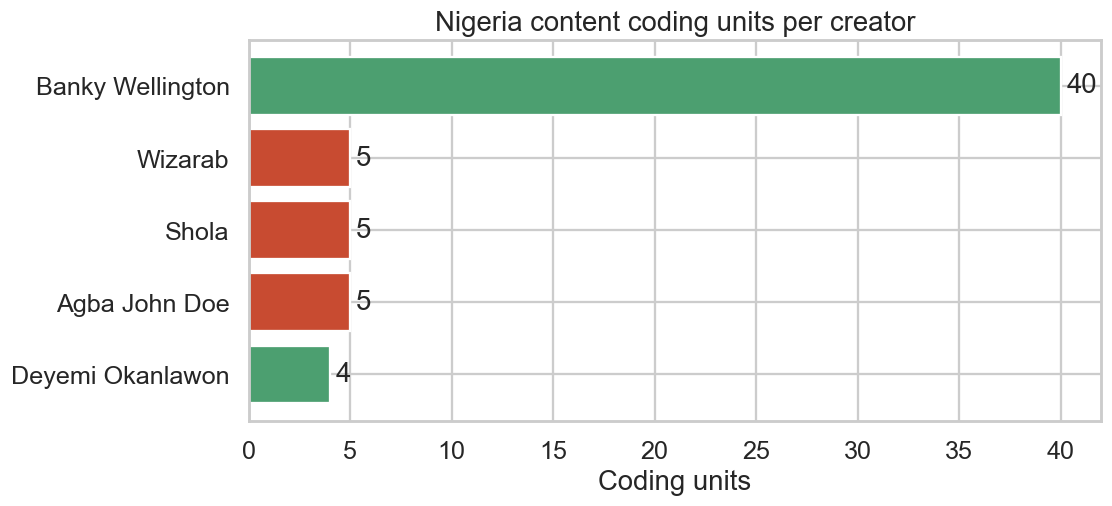

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = summary_out.sort_values("units", ascending=True)
colors = {"Banky Wellington": "#4C9F70", "Deyemi Okanlawon": "#4C9F70",
          "Wizarab": "#C84B31", "Shola": "#C84B31", "Agba John Doe": "#C84B31"}
ax.barh(order["influencer"], order["units"],
        color=[colors.get(i, "#888") for i in order["influencer"]])
for i, n in enumerate(order["units"]):
    ax.text(n + 0.3, i, str(n), va="center")
ax.set_title("Nigeria content coding units per creator")
ax.set_xlabel("Coding units")
plt.savefig(PLOTS_DIR / "01_units_per_creator.png")
plt.show()


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_8389/3779985758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=corpus, y="Influencer", x="n_words", ax=ax, palette="Blues")


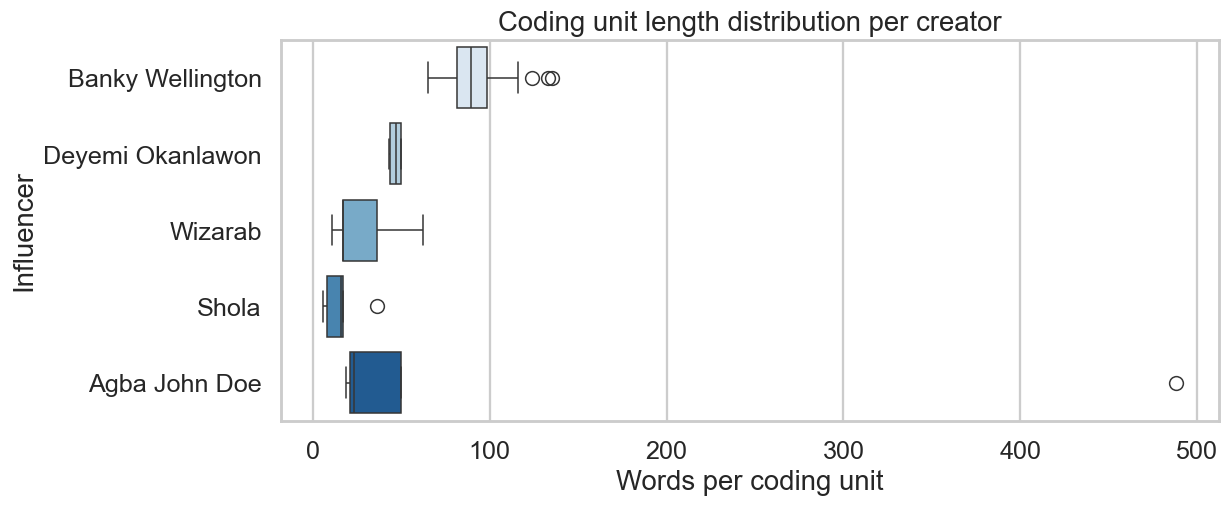

In [8]:
corpus["n_words"] = corpus["Verbatim Text (CODE THIS)"].str.split().str.len()
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=corpus, y="Influencer", x="n_words", ax=ax, palette="Blues")
ax.set_xlabel("Words per coding unit")
ax.set_title("Coding unit length distribution per creator")
plt.savefig(PLOTS_DIR / "02_unit_word_counts.png")
plt.show()


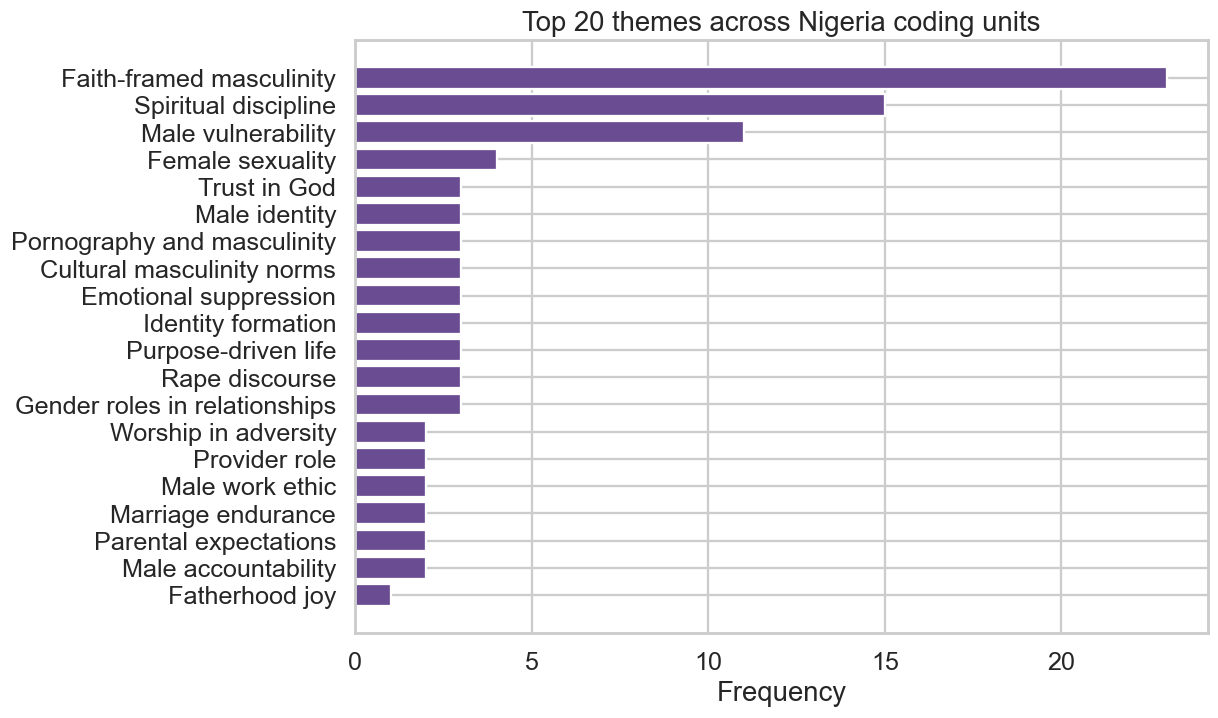

,theme,count
0,Faith-framed masculinity,23
1,Spiritual discipline,15
2,Male vulnerability,11
3,Female sexuality,4
4,Trust in God,3
5,Male identity,3
6,Pornography and masculinity,3
7,Cultural masculinity norms,3
8,Emotional suppression,3
9,Identity formation,3


In [9]:
from collections import Counter
tc = Counter()
for t in corpus["Theme(s)"]:
    if not isinstance(t, str):
        continue
    for theme in [p.strip() for p in t.split(";") if p.strip()]:
        tc[theme] += 1
top = pd.DataFrame(tc.most_common(20), columns=["theme", "count"])
if len(top):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top["theme"][::-1], top["count"][::-1], color="#6A4C93")
    ax.set_title("Top 20 themes across Nigeria coding units")
    ax.set_xlabel("Frequency")
    plt.savefig(PLOTS_DIR / "03_top_themes.png")
    plt.show()
top


## Notes

- LLM calls are cached under `temp/content_analysis_nigeria/`. Re-runs are free unless the cache is deleted.
- Verbatim text preservation is enforced by prompt — cross-check a sample against the original transcripts before coding begins.
- Deyemi has 4 units per the selection memo; add a 5th post to `X_POSTS["Deyemi Okanlawon"]["posts"]` to bring him to 5.
